In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from google.colab import drive
drive.mount('/content/drive')
c_path = '/content/drive/MyDrive/Colab Notebooks/credit_record.csv'
c_data = pd.read_csv(c_path)
path = '/content/drive/MyDrive/Colab Notebooks/application_record.csv'
data = pd.read_csv(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
data.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [ ]:
data.shape

(438557, 18)

In [ ]:
data.rename(columns={'ID': 'Id',
'CODE_GENDER':'Sex',
'FLAG_OWN_CAR':'Car_flag','FLAG_OWN_REALTY':'Reality',
'CNT_CHILDREN':'Children','AMT_INCOME_TOTAL':'Income_sum',
'NAME_EDUCATION_TYPE':'Education','NAME_FAMILY_STATUS':'Family_status',
'NAME_HOUSING_TYPE':'House_type','FLAG_EMAIL':'Email',
'NAME_INCOME_TYPE':'Income_type','FLAG_WORK_PHONE':'Wrk_phone',
'FLAG_PHONE':'Phone','CNT_FAM_MEMBERS':'Family_count',
'OCCUPATION_TYPE':'Occupation_type',
'DAYS_BIRTH': 'Birthday', 'DAYS_EMPLOYED': 'Employed_days',
'FLAG_MOBIL': 'Mobile_p'}, inplace=True)

In [ ]:
c_data.rename(columns={'ID': 'Id',
'MONTHS_BALANCE': 'MONTHS_BALANCE'.capitalize(),
'STATUS':'STATUS'.capitalize()}, inplace=True)

In [ ]:
c_data.head()

,Id,Months_balance,Status
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [ ]:
# проверка пустых значений в Employed_days и замена дефолтных значений на медиану
# data['Employed_days'].isnull().sum()
# замена отрицательных значений в столбце на положительные для добавления логики отказа
# data['Employed_days'] = data['Employed_days'].apply(lambda x: abs(x))
# Добавление столбца с флагом(значение 365243)
# data['Employed_days_is_365243'] = (data['Employed_days'] == 365243).astype(int)
# Заполнение поля Employed_days медианой для значений 365243
# med = data.loc[data['Employed_days'] != 365243, 'Employed_days'].median()
# data.loc[data['Employed_days'] == 365243, 'Employed_days'] = med

In [ ]:
# проверка пустых значений в Employed_days и замена дефолтных значений на медиану + шум, т.к. только медиана дает "иглу" значений
# 1. Замена отрицательных значений в столбце на положительные для добавления логики отказа
data['Employed_days'] = data['Employed_days'].apply(lambda x: abs(x))

# 2. Флаг для понимая, где было значение 365243
mask = (data['Employed_days'] == 365243)
data['Employed_days_is_365243'] = mask.astype(int)

# 3. Подсчет статистики по "нормальным" значениям
base = data.loc[~mask, 'Employed_days']
med = base.median()
q1 = base.quantile(0.25)
q3 = base.quantile(0.75)
iqr = q3 - q1

# 4. Генератор случайных чисел для управления заменой значения 365243
rng = np.random.default_rng(42)

# 5. Шум для добавления к медиане
sigma = max(1.0, 0.15 * iqr)    # 0.10 - 0.25
noise = rng.normal(0, sigma, size=mask.sum())
new_vals = med + noise

# 6. Ограничение границы
low = max(0, q1 - 1.5 * iqr)  # нижняя граница
high = base.quantile(0.99)  # верхняя граница
new_vals = np.clip(new_vals, low, high)

# 7. Финальный результат
data.loc[mask, 'Employed_days'] = np.round(new_vals).astype(int)

In [ ]:
from datetime import datetime, timedelta
def find_birthday(date_f):
    # Получаем дату дня рождения
    current_date = datetime.now()
    new_date = current_date - timedelta(days=abs(date_f))
    return new_date.strftime('%Y-%m-%d')

# проверка пустых значений в Birthday
data['Birthday'].isnull().sum()
# замена отрицательных значений в столбце на положительные для добавления логики отказа
data['Birthday'] = data['Birthday'].apply(lambda x: find_birthday(x))

In [ ]:
from datetime import date

def age_now(asd):
    born = date(int(asd.split('-')[0]), int(asd.split('-')[1]), int(asd.split('-')[2]))
    today = date.today()
    # Разница лет минус 1, если день рождения еще не прошел
    return today.year - born.year - ((today.month, today.day) < (born.month, born.day))

# Новый столбец с возрастом
data['Age'] = data['Birthday'].apply(age_now)

In [ ]:
data.head()

,Id,Sex,Car_flag,Reality,Children,Income_sum,Income_type,Education,Family_status,House_type,Birthday,Employed_days,Mobile_p,Wrk_phone,Phone,Email,Occupation_type,Family_count,Employed_days_is_365243,Age
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1993-04-29,4542,1,1,0,0,NaN,2.0,0,32
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,1993-04-29,4542,1,1,0,0,NaN,2.0,0,32
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,1967-05-27,1134,1,0,0,0,Security staff,2.0,0,58
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1973-11-15,3051,1,0,1,1,Sales staff,1.0,0,52
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,1973-11-15,3051,1,0,1,1,Sales staff,1.0,0,52


In [ ]:
# Добавление столбца со стажем в годах
data['Employed_years'] = data['Employed_days'].apply(lambda x: x / 365.25)

## Добавление отказов

In [ ]:
# 1. Отказ из-за нестабильности(возраст, стаж, нестабильный тип дохода)
def decline_AgeEmployment(row):
    if row['Age'] < 21 or row['Age'] > 70 or row['Employed_years'] <= 1 or (row['Income_type'] in ['Student', 'Pensioner']):
        return 1
    else:
        return 0

data['Decline_AgeEmployment'] = data.apply(decline_AgeEmployment, axis=1)

In [ ]:
# 2. Отказ по платёжеспособности(низкий доход, высокая нагрузка, отсутствие активов/аренда)
income_median = data['Income_sum'].median()

def decline_AffordabilityStress(row):
    conditions = [
        (row['Family_count'] >= 4) or (row['Children'] >= 2),
        row['House_type'] in ['Rented apartment', 'With parents'],
        (row['Car_flag'] == 0) and (row['Reality'] == 0),
    ]
    return int((row['Income_sum'] < income_median) and (sum(conditions) >= 2))

data['Decline_AffordabilityStress'] = data.apply(decline_AffordabilityStress, axis=1)

In [ ]:
# 3. Отказ из-за малого кол-ва данных о человеке
def decline_DataContactRisk(row):
    if (row['Mobile_p'] == 0 or (row['Wrk_phone'] == 0 and row['Phone'] == 0))and (pd.isna(row['Occupation_type']) or row['Employed_years'] <= 1):
        return 1
    else:
        return 0

data['Decline_DataContactRisk'] = data.apply(decline_DataContactRisk, axis=1)

In [ ]:
# Общий столбец со всеми отказами(ALL)
def decline_All(row):
    deecline = [
        row['Decline_AgeEmployment'] == 1,
        row['Decline_AffordabilityStress'] == 1,
        row['Decline_DataContactRisk'] == 1
    ]
    return int(all(deecline))

data['Decline_All'] = data.apply(decline_All, axis=1)

In [ ]:
# Информация(агрегаты) по отказникам для ALL
data.groupby('Decline_All')['Income_sum'].agg(['min', 'max', 'mean', 'median', 'sum'])

,min,max,mean,median,sum
Decline_All,,,,,
0,26100.0,6750000.0,187534.357852,162000.0,8.223044e+10
1,67500.0,157500.0,128640.000000,135000.0,9.648000e+06


In [ ]:
# Общий столбец со всеми отказами(ANY)
def decline_Any(row):
    deecline = [
        row['Decline_AgeEmployment'] == 1,
        row['Decline_AffordabilityStress'] == 1,
        row['Decline_DataContactRisk'] == 1
    ]
    return int(any(deecline))

data['Decline_Any'] = data.apply(decline_Any, axis=1)

In [ ]:
# Информация(агрегаты) по отказникам для ANY
data.groupby('Decline_Any')['Income_sum'].agg(['min', 'max', 'mean', 'median', 'sum'])

,min,max,mean,median,sum
Decline_Any,,,,,
0,27000.0,6750000.0,196141.849026,180000.0,5.821353e+10
1,26100.0,1575000.0,169482.805942,157500.0,2.402656e+10


In [ ]:
# Общий % отказов
# Отказ 1
Decline_AgeEmployment_count = (data['Decline_AgeEmployment'] == 1).sum()
Decline_AgeEmployment_pro = round(Decline_AgeEmployment_count * 100 / data.shape[0], 2)
# Отказ 2
Decline_AffordabilityStress_count = (data['Decline_AffordabilityStress'] == 1).sum()
Decline_AffordabilityStress_pro = round(Decline_AffordabilityStress_count * 100 / data.shape[0], 2)
# Отказ 3
Decline_DataContactRisk_count = (data['Decline_DataContactRisk'] == 1).sum()
Decline_DataContactRisk_pro = round(Decline_DataContactRisk_count * 100 / data.shape[0], 2)
print(f"Decline_AgeEmployment_pro: {Decline_AgeEmployment_pro}\nDecline_AffordabilityStress_pro: {Decline_AffordabilityStress_pro}\nDecline_DataContactRisk_pro: {Decline_DataContactRisk_pro}")
# Финальный отказ(все отказы, сработавшие для одного клиента)
Decline_All_count = (data['Decline_All'] == 1).sum() # 2 версия data.loc[data['Decline_All'] == 1, ['Decline_All']].shape[0]
Decline_All_pro = round(Decline_All_count * 100 / data.shape[0], 2)
print(f"Decline_All_count: {Decline_All_count}\nDecline_All_pro: {Decline_All_pro}")
# Финальный отказ(как минимум один, сработавший отказ для одного клиента)
Decline_Any_count = (data['Decline_Any'] == 1).sum() # 2 версия data.loc[data['Decline_Any'] == 1, ['Decline_Any']].shape[0]
Decline_Any_pro = round(Decline_Any_count * 100 / data.shape[0], 2)
print(f"Decline_Any_count: {Decline_Any_count}\nDecline_Any_pro: {Decline_Any_pro}")

Decline_AgeEmployment_pro: 24.9
Decline_AffordabilityStress_pro: 0.31
Decline_DataContactRisk_pro: 24.03
Decline_All_count: 75
Decline_All_pro: 0.02
Decline_Any_count: 141764
Decline_Any_pro: 32.33


In [ ]:
# Подчет потери Income для всех у кого 3 отказа и у кого минимум 1 отказ
Count_income_All = round(data.loc[data['Decline_All'] == 1, 'Income_sum'].sum(), 2)
Count_income_Any = round(data.loc[data['Decline_Any'] == 1, 'Income_sum'].sum(), 2)
print(f"Sum_income: {data['Income_sum'].sum()}\n"
      f"Count_income_All: {Count_income_All}\n"
      f"Count_income_Any: {Count_income_Any}")

Sum_income: 82240088299.47
Count_income_All: 9648000.0
Count_income_Any: 24026560501.5


In [ ]:
# Универсальная функция для сегменатции доли отказов
def decline_by_segment(df, segment_col, decline_col="Decline_Any", min_n=50):
    """
    df - DataFrame
    segment_col - колонка, по которой выбирать клиентов на сегменты(корреляция любой колонки на отказ)
    decline_col - колонка с отказом("Decline_Any" - default,где должно быть 0 или 1)
    min_n - минимальный размер сегмента для мелких выборок, чтобы его показывать(50 - default)
    """
    out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))
    """
    n - кол-во строк(клиентов) в сегменте
    decline - сумма отказных значений Decline_Any внутри группы(сколько людей со значением 1)
    decline_rate - среднее значение Decline_Any(кол-во отказов / кол-во людей всего)
    """
    out["decline_rate"] = out["decline_rate"] * 100  # перевод в %
    # out = out[out["n"] >= min_n]  # для очень маленьких выборок
    return out

In [ ]:
# 1. Отказы по бинам возраста(Age bins)
# pd.cut() - разбиение числового столбца на интервалы(бины) и возвращать категории(бины) для каждой строки
# right=False - левая граница интервалов включена, правая - нет
age_bins = [18, 25, 35, 45, 55, 65, 200]
age_labels = ["18-24", "25-34", "35-44", "45-54", "55-64", "65+"]

data["Age_bin"] = pd.cut(data["Age"], bins=age_bins, labels=age_labels, right=False)
age_stats = decline_by_segment(data, "Age_bin", decline_col="Decline_Any", min_n=50).sort_index()
age_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Age_bin,,,
18-24,10360,3222,31.100386
25-34,108294,22585,20.855264
35-44,126981,22533,17.745174
45-54,100847,23117,22.922844
55-64,85447,64041,74.948214
65+,6628,6266,94.538322


In [ ]:
# 2. Доход(квантили Q1-Q4 или Q1-Q10)
# pd.qcut() - cut по квантилям
data["Income_q4"] = pd.qcut(data["Income_sum"], q=4, labels=["Q1", "Q2", "Q3", "Q4"])
income_q4_stats = decline_by_segment(data, "Income_q4", "Decline_Any")
income_q4_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Income_q4,,,
Q1,112499,45911,40.810141
Q2,106782,36338,34.030080
Q3,126650,37106,29.298066
Q4,92626,22409,24.192991


In [ ]:
data["Income_q10"] = pd.qcut(data["Income_sum"], q=10, labels=[f"Q{i}" for i in range(1, 11)])
income_q10_stats = decline_by_segment(data, "Income_q10", "Decline_Any")
income_q10_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Income_q10,,,
Q1,53474,24159,45.178965
Q2,50155,18258,36.403150
Q3,64838,22803,35.169191
Q4,8949,3474,38.819980
Q5,41865,13555,32.377881
Q6,50592,15345,30.330882
Q7,38116,11261,29.544024
Q8,52074,14065,27.009640
Q9,45399,11125,24.504945


In [ ]:
# 3. По семейной нагрузке
data["Family_bin"] = pd.cut(data["Family_count"], bins=[0, 1, 2, 3, 4, 100], labels=["1", "2", "3", "4", "5+"], right=True)
family_stats = decline_by_segment(data, "Family_bin", "Decline_Any")
family_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Family_bin,,,
1,84492,35556,42.082091
2,233891,81719,34.938925
3,77128,15633,20.268904
4,37356,7715,20.652639
5+,5690,1141,20.052724


In [ ]:
# 4. По кол-ву детей
data["Children_bin"] = pd.cut(data["Children"], bins=[-1, 0, 1, 2, 100], labels=["0", "1", "2", "3+"], right=True)
children_stats = decline_by_segment(data, "Children_bin", "Decline_Any")
children_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Children_bin,,,
0,304071,113887,37.454081
1,88527,18270,20.637772
2,39884,8349,20.933206
3+,6075,1258,20.707819


In [ ]:
# 4. По типу жилья
house_stats = decline_by_segment(data, "House_type", "Decline_Any", min_n=100)
house_stats

,n,declined,decline_rate
House_type,,,
Co-op apartment,1539,409,26.575699
House / apartment,393831,129025,32.761514
Municipal apartment,14214,4480,31.518221
Office apartment,3922,990,25.242223
Rented apartment,5974,1710,28.624037
With parents,19077,5150,26.995859


In [ ]:
# 5. По кол-ву лет стажа
emp_bins = [0, 1, 3, 5, 10, 100]
emp_labels = ["0-1", "1-3", "3-5", "5-10", "10+"]

data["Emp_bin"] = pd.cut(data["Employed_years"], bins=emp_bins, labels=emp_labels, right=False)

emp_stats = decline_by_segment(data, "Emp_bin", "Decline_Any", min_n=50).sort_index()
emp_stats

/tmp/ipykernel_1447/1927638197.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  out = (df.groupby(segment_col)[decline_col].agg(n="size", declined="sum", decline_rate="mean"))


,n,declined,decline_rate
Emp_bin,,,
0-1,33684,33684,100.000000
1-3,77535,9454,12.193203
3-5,93311,34828,37.324646
5-10,149113,55514,37.229484
10+,84914,8284,9.755753


In [ ]:
# 6. Проверка каналов связи(Contact_channels - кол-во каналов связи)
data["Contact_channels"] = data[["Mobile_p", "Phone", "Wrk_phone", "Email"]].sum(axis=1)

contact_stats = decline_by_segment(data, "Contact_channels", "Decline_Any", min_n=1)
contact_stats

,n,declined,decline_rate
Contact_channels,,,
1,239962,95933,39.978413
2,136986,39288,28.680303
3,57753,6126,10.607241
4,3856,417,10.814315


## Визуальная часть

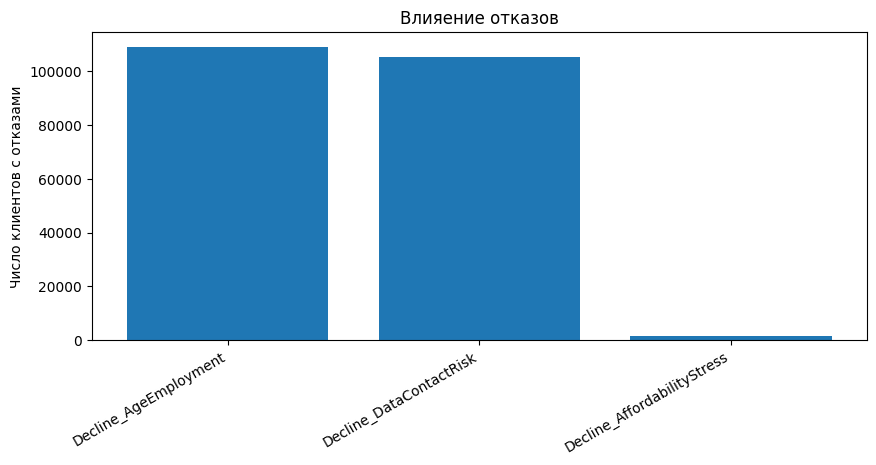

In [ ]:
# Общий график с кол-ом отказов
decline_cols = ["Decline_AgeEmployment", "Decline_AffordabilityStress", "Decline_DataContactRisk"]
combo_delines = data[decline_cols].sum().sort_values(ascending=False)
plt.figure(figsize=(10, 4))
plt.bar(combo_delines.index, combo_delines.values)
plt.xticks(rotation=30, ha="right")
plt.ylabel("Число клиентов с отказами")
plt.title("Влияение отказов")
plt.show()

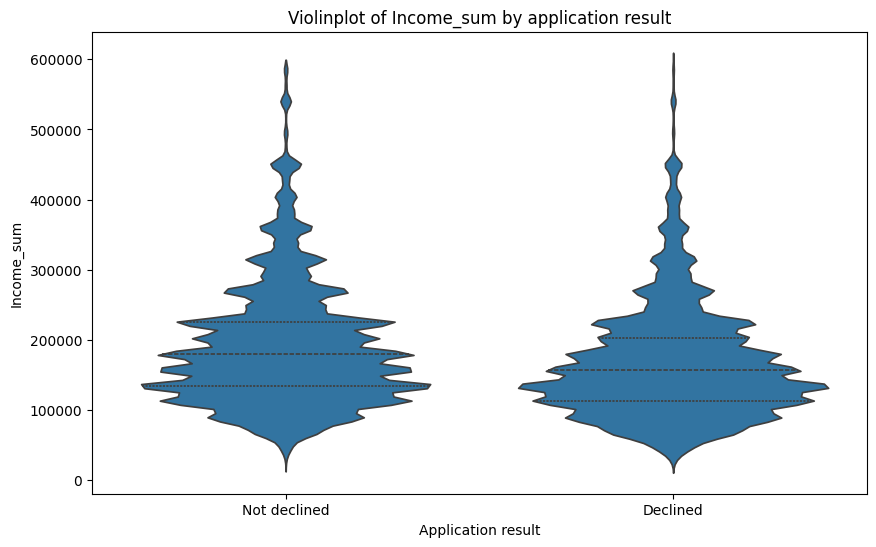

In [ ]:
plot_data = data.copy()
plot_data = plot_data.dropna(subset=['Income_sum', 'Decline_Any'])
plot_data = plot_data[plot_data['Income_sum'] <= 600000]  # УБРАЛ ВЫБРОСЫ <= 600000

plot_data['Decline_label'] = plot_data['Decline_Any'].map({
    0: 'Not declined',
    1: 'Declined'
})

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='Decline_label',
    y='Income_sum',
    inner='quartile'
)

plt.title('Violinplot of Income_sum by application result')
plt.xlabel('Application result')
plt.ylabel('Income_sum')
plt.show()

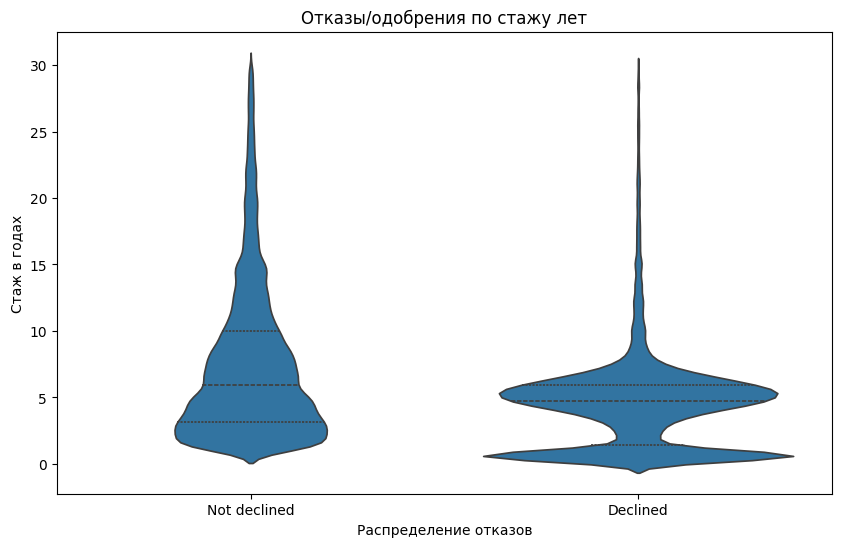

In [ ]:
plot_data = data.copy()
plot_data = plot_data.dropna(subset=['Employed_years', 'Decline_Any'])
plot_data = plot_data[plot_data['Employed_years'] <= 30]  # УБРАЛ ВЫБРОСЫ

plot_data['Decline_label'] = plot_data['Decline_Any'].map({
    0: 'Not declined',
    1: 'Declined'
})

plt.figure(figsize=(10, 6))

sns.violinplot(
    data=plot_data,
    x='Decline_label',
    y='Employed_years',
    inner='quartile'
)

plt.title('Отказы/одобрения по стажу лет')
plt.xlabel('Распределение отказов')
plt.ylabel('Стаж в годах')
plt.show()

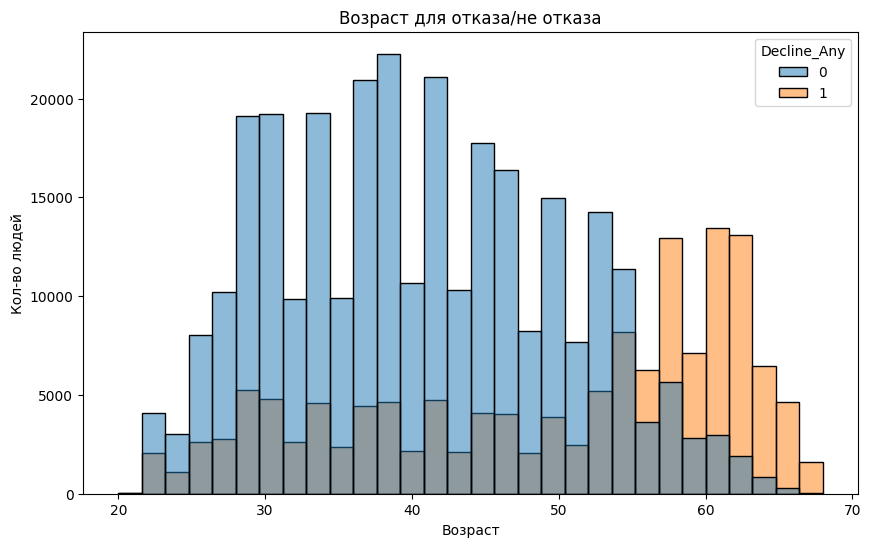

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(
    data=data,
    x='Age',
    hue='Decline_Any',
    bins=30,
    multiple='layer',   # 'stack' или 'dodge' или 'layer'
    alpha=0.5
)

plt.title('Возраст для отказа/не отказа')
plt.xlabel('Возраст')
plt.ylabel('Кол-во людей')
plt.show()